**Student Name:** Adnan Ali  
**Student code:** iitp_aiml_25061026 
**Project:** Capstone Project  
**Project Part:** Part 1 – Data Audit, EDA & Business Understanding


# D2C Customer Churn Intelligence & Retention API

## Part 1: Data Audit, EDA & Business Understanding

### Objective
The objective of this analysis is to understand customer behavior, identify data quality issues, explore churn-related patterns, and generate business insights that can support customer retention strategies.

### Dataset Used
- customers.csv
- orders.csv
- support_tickets.csv
- web_events_snapshot.csv
- churn_labels.csv
- intervention_history.csv

### Analysis Covered
1. Data loading and inspection
2. Data quality assessment
3. Missing value analysis
4. Duplicate detection
5. Outlier analysis
6. Customer behavior analysis
7. Churn-related business insights
8. Retention hypotheses

## Import Libraries and Load Dataset

In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

customers = pd.read_csv("../../dataset/customers.csv")
orders = pd.read_csv("../../dataset/orders.csv")
support = pd.read_csv("../../dataset/support_tickets.csv")
web = pd.read_csv("../../dataset/web_events_snapshot.csv")
churn = pd.read_csv("../../dataset/churn_labels.csv")
intervention = pd.read_csv("../../dataset/intervention_history.csv")

print("Customers:", customers.shape)
print("Orders:", orders.shape)
print("Support:", support.shape)
print("Web Events:", web.shape)
print("Churn Labels:", churn.shape)
print("Intervention:", intervention.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Support: (1921, 8)
Web Events: (2400, 10)
Churn Labels: (2400, 4)
Intervention: (2400, 5)


## Dataset Overview
The project contains six datasets:

1. Customers
2. Orders
3. Support Tickets
4. Web Events Snapshot
5. Churn Labels
6. Intervention History

These datasets will be audited, cleaned, analyzed, and merged to generate business insights related to customer churn.

In [258]:
dataset_summary = pd.DataFrame({
    "Dataset": [
        "Customers",
        "Orders",
        "Support Tickets",
        "Web Events",
        "Churn Labels",
        "Intervention History"
    ],
    "Rows": [
        customers.shape[0],
        orders.shape[0],
        support.shape[0],
        web.shape[0],
        churn.shape[0],
        intervention.shape[0]
    ],
    "Columns": [
        customers.shape[1],
        orders.shape[1],
        support.shape[1],
        web.shape[1],
        churn.shape[1],
        intervention.shape[1]
    ]
})

dataset_summary

,Dataset,Rows,Columns
0,Customers,2400,9
1,Orders,10009,10
2,Support Tickets,1921,8
3,Web Events,2400,10
4,Churn Labels,2400,4
5,Intervention History,2400,5


## Data Audit

The purpose of this section is to:

- Understand schema and datatypes
- Identify missing values
- Detect duplicate records
- Examine data quality issues
- Generate a formal data quality report

In [259]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   signup_date          2400 non-null   object
 2   city_tier            2400 non-null   object
 3   age_group            2400 non-null   object
 4   acquisition_channel  2400 non-null   object
 5   loyalty_tier         1014 non-null   object
 6   preferred_category   2400 non-null   object
 7   skin_type            1999 non-null   object
 8   marketing_consent    2400 non-null   object
dtypes: object(9)
memory usage: 168.9+ KB


In [260]:
customers.head()

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes


In [261]:
customers.describe(include="all")

,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent
count,2400,2400,2400,2400,2400,1014,2400,1999,2400
unique,2400,609,3,4,6,3,6,5,2
top,CUST00001,2024-10-12,Tier 1,25-34,Instagram,Silver,Skin Care,Oily,Yes
freq,1,11,1005,1045,517,590,731,420,1760


In [262]:
customers.isnull().sum()

customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64

In [263]:
customers.duplicated().sum()

np.int64(0)

In [264]:
for col in customers.columns:
    print(f"\n{col}")
    print(customers[col].nunique())


customer_id
2400

signup_date
609

city_tier
3

age_group
4

acquisition_channel
6

loyalty_tier
3

preferred_category
6

skin_type
5

marketing_consent
2


## Customers Dataset - Audit Summary

### Data Quality Findings

1. No duplicate customer records were found.

2. loyalty_tier contains 1,386 missing values (57.75% of records), indicating incomplete loyalty-program information.

3. skin_type contains 401 missing values (16.71% of records).

4. customer_id appears unique and can be treated as the primary identifier.

5. Customer acquisition channel, city tier, preferred category, and marketing consent may be valuable variables for churn analysis and retention planning.

### Business Implications

- Missing loyalty information may reduce the ability to identify high-value customers.
- Marketing consent can be used for future retention campaigns.
- Acquisition channels may reveal which customer sources produce loyal customers versus churn-prone customers.

Total Customers: 2400
Duplicate Records: 0

Missing Values:
- loyalty_tier: 1386 (57.75%)
- skin_type: 401 (16.71%)

Unique Values:
- city_tier: 3
- age_group: 4
- acquisition_channel: 6
- loyalty_tier: 3
- preferred_category: 6
- skin_type: 5
- marketing_consent: 2

## Orders Dataset Audit

The orders dataset contains customer transaction history and will be used to understand purchasing behavior, revenue contribution, and customer engagement patterns.

In [265]:
orders.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10009 entries, 0 to 10008
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       10009 non-null  object 
 1   customer_id    10009 non-null  object 
 2   order_date     10009 non-null  object 
 3   category       10009 non-null  object 
 4   quantity       10009 non-null  int64  
 5   gross_amount   10009 non-null  float64
 6   discount_pct   10009 non-null  float64
 7   delivery_days  10009 non-null  int64  
 8   returned       10009 non-null  int64  
 9   rating         9929 non-null   float64
dtypes: float64(3), int64(3), object(4)
memory usage: 782.1+ KB


In [266]:
orders.head()

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
0,ORD000001,CUST00001,2024-08-06,Skin Care,1,540.70,0.43,3,0,4.0
1,ORD000002,CUST00001,2024-10-23,Hair Care,2,467.96,0.64,4,1,1.0
2,ORD000006,CUST00001,2025-01-18,Makeup,1,581.81,0.27,7,0,4.0
3,ORD000005,CUST00001,2025-01-22,Hair Care,1,433.15,0.27,2,0,4.0
4,ORD000004,CUST00001,2025-02-28,Skin Care,1,569.22,0.34,4,0,4.0


In [267]:
orders.isnull().sum()

order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64

In [268]:
orders.duplicated().sum()

np.int64(0)

In [269]:
orders.describe(include="all")

,order_id,customer_id,order_date,category,quantity,gross_amount,discount_pct,delivery_days,returned,rating
count,10009,10009,10009,10009,10009.000000,10009.000000,10009.000000,10009.000000,10009.000000,9929.000000
unique,10009,2400,674,6,NaN,NaN,NaN,NaN,NaN,NaN
top,ORD000001,CUST02154,2025-10-01,Skin Care,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,17,42,2700,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,1.507943,743.898504,0.274121,4.454591,0.067439,3.885487
std,NaN,NaN,NaN,NaN,0.764261,600.564068,0.125525,1.769649,0.250794,1.159465
min,NaN,NaN,NaN,NaN,1.000000,149.000000,0.000000,1.000000,0.000000,1.000000
25%,NaN,NaN,NaN,NaN,1.000000,432.850000,0.190000,3.000000,0.000000,3.000000
50%,NaN,NaN,NaN,NaN,1.000000,597.060000,0.270000,4.000000,0.000000,4.000000
75%,NaN,NaN,NaN,NaN,2.000000,907.430000,0.360000,6.000000,0.000000,5.000000


## Support Tickets Dataset Audit

The support tickets dataset contains customer complaints and service interactions. It helps identify dissatisfaction signals that may contribute to customer churn.

In [270]:
support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1921 entries, 0 to 1920
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticket_id         1921 non-null   object 
 1   customer_id       1921 non-null   object 
 2   ticket_date       1921 non-null   object 
 3   issue_type        1921 non-null   object 
 4   support_channel   1921 non-null   object 
 5   resolution_hours  1921 non-null   float64
 6   sentiment_score   1921 non-null   float64
 7   reopened          1921 non-null   int64  
dtypes: float64(2), int64(1), object(5)
memory usage: 120.2+ KB


In [271]:
support.head()

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
0,TKT000001,CUST00001,2024-10-28,damaged_item,chat,3.9,-0.16,0
1,TKT000002,CUST00001,2025-02-03,payment_issue,chat,4.8,0.44,0
2,TKT000003,CUST00002,2025-08-30,late_delivery,chat,1.0,0.00,0
3,TKT000004,CUST00005,2025-05-02,late_delivery,call,37.7,-1.00,0
4,TKT000005,CUST00006,2025-08-13,general_query,call,23.1,-0.68,1


In [272]:
support.isnull().sum()

ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64

In [273]:
support.duplicated().sum()

np.int64(0)

In [274]:
support.describe(include="all")

,ticket_id,customer_id,ticket_date,issue_type,support_channel,resolution_hours,sentiment_score,reopened
count,1921,1921,1921,1921,1921,1921.000000,1921.000000,1921.000000
unique,1921,1247,526,7,3,NaN,NaN,NaN
top,TKT000001,CUST00487,2025-09-30,late_delivery,email,NaN,NaN,NaN
freq,1,6,51,377,671,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,24.789276,-0.440770,0.176991
std,NaN,NaN,NaN,NaN,NaN,14.270666,0.473244,0.381761
min,NaN,NaN,NaN,NaN,NaN,1.000000,-1.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,14.400000,-0.890000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,24.200000,-0.490000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,34.600000,-0.110000,0.000000


In [275]:
for col in support.columns:
    print(f"\n{col}")
    print(support[col].nunique())


ticket_id
1921

customer_id
1247

ticket_date
526

issue_type
7

support_channel
3

resolution_hours
525

sentiment_score
181

reopened
2


### Support Tickets Dataset Findings

- Total records: 1,921
- Unique customers with tickets: 1,247
- Missing values: None
- Duplicate records: 0

Business Insights:

- 7 unique issue types
- 3 support channels (email, call, chat)
- Average resolution time: 24.79 hours
- Average sentiment score: -0.44
- Ticket reopen rate: 17.7%

Potential Churn Signals:

- Negative sentiment score
- High resolution time
- Reopened tickets
- Frequent support interactions

## Web Events Dataset Audit

This dataset captures customer engagement and activity on the website. It provides important behavioural signals that may indicate future churn risk.

In [276]:
web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          2400 non-null   object
 1   snapshot_date        2400 non-null   object
 2   sessions_30d         2400 non-null   int64 
 3   product_views_30d    2400 non-null   int64 
 4   cart_adds_30d        2400 non-null   int64 
 5   wishlist_adds_30d    2400 non-null   int64 
 6   abandoned_carts_30d  2400 non-null   int64 
 7   email_opens_30d      2400 non-null   int64 
 8   campaign_clicks_30d  2400 non-null   int64 
 9   last_visit_days_ago  2400 non-null   int64 
dtypes: int64(8), object(2)
memory usage: 187.6+ KB


In [277]:
web.head()

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
0,CUST00001,2025-09-30,1,4,0,0,0,2,0,20
1,CUST00002,2025-09-30,8,31,4,2,3,0,0,0
2,CUST00003,2025-09-30,1,3,0,0,0,0,0,26
3,CUST00004,2025-09-30,1,6,0,0,0,0,0,14
4,CUST00005,2025-09-30,18,95,4,1,1,3,1,9


In [278]:
web.isnull().sum()

customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        0
campaign_clicks_30d    0
last_visit_days_ago    0
dtype: int64

In [279]:
web.duplicated().sum()

np.int64(0)

In [280]:
web.describe(include="all")

,customer_id,snapshot_date,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago
count,2400,2400,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000,2400.000000
unique,2400,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,CUST00001,2025-09-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,2400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,5.460000,23.021667,1.560833,0.839167,0.672917,2.645833,0.649583,17.652500
std,NaN,NaN,4.400167,19.818043,1.644919,0.996015,0.867225,2.763346,0.951579,15.905806
min,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,2.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
50%,NaN,NaN,5.000000,18.000000,1.000000,1.000000,0.000000,2.000000,0.000000,14.000000
75%,NaN,NaN,8.000000,34.000000,2.000000,1.000000,1.000000,5.000000,1.000000,27.000000


In [281]:
for col in web.columns:
    print(f"\n{col}")
    print(web[col].nunique())


customer_id
2400

snapshot_date
1

sessions_30d
24

product_views_30d
101

cart_adds_30d
13

wishlist_adds_30d
7

abandoned_carts_30d
7

email_opens_30d
14

campaign_clicks_30d
7

last_visit_days_ago
61


### Web Events Dataset Findings

- Total records: 2,400
- Missing values: None
- Duplicate records: 0

Behavior Metrics Summary:

- Average sessions in last 30 days: 5.46
- Average product views: 23.02
- Average cart additions: 1.56
- Average wishlist additions: 0.84
- Average abandoned carts: 0.67
- Average email opens: 2.65
- Average campaign clicks: 0.65
- Average last visit age: 17.65 days

Potential Churn Signals:

- Low sessions and product views
- High last_visit_days_ago
- Low email engagement
- High abandoned carts
- Low campaign interaction

## Churn Labels Dataset Audit

This dataset contains the target variable for churn prediction and is critical for understanding customer retention behavior.

In [282]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customer_id     2400 non-null   object
 1   snapshot_date   2400 non-null   object
 2   churn_next_60d  2400 non-null   int64 
 3   split           2400 non-null   object
dtypes: int64(1), object(3)
memory usage: 75.1+ KB


In [283]:
churn.head()

,customer_id,snapshot_date,churn_next_60d,split
0,CUST00001,2025-09-30,1,train
1,CUST00002,2025-09-30,0,train
2,CUST00003,2025-09-30,1,train
3,CUST00004,2025-09-30,1,train
4,CUST00005,2025-09-30,0,train


In [284]:
churn.isnull().sum()

customer_id       0
snapshot_date     0
churn_next_60d    0
split             0
dtype: int64

In [285]:
churn.duplicated().sum()

np.int64(0)

In [286]:
churn.describe(include="all")

,customer_id,snapshot_date,churn_next_60d,split
count,2400,2400,2400.000000,2400
unique,2400,1,NaN,3
top,CUST00001,2025-09-30,NaN,train
freq,1,2400,NaN,1728
mean,NaN,NaN,0.469583,NaN
std,NaN,NaN,0.499178,NaN
min,NaN,NaN,0.000000,NaN
25%,NaN,NaN,0.000000,NaN
50%,NaN,NaN,0.000000,NaN
75%,NaN,NaN,1.000000,NaN


In [287]:
for col in churn.columns:
    print(f"\n{col}")
    print(churn[col].nunique())


customer_id
2400

snapshot_date
1

churn_next_60d
2

split
3


In [288]:
churn["churn_next_60d"].value_counts()

churn_next_60d
0    1273
1    1127
Name: count, dtype: int64

In [289]:
churn["churn_next_60d"].value_counts(normalize=True)*100

churn_next_60d
0    53.041667
1    46.958333
Name: proportion, dtype: float64

### Churn Labels Dataset Findings

- Total records: 2,400
- Missing values: None
- Duplicate records: 0

Target Variable Information:

- churn_next_60d is the target variable
- Binary classification problem:
  - 0 = Customer Retained
  - 1 = Customer Churned

Churn Distribution:

| Class | Count | Percentage |
|---------|---------|---------|
| Retained (0) | 1273 | 53.04% |
| Churned (1) | 1127 | 46.96% |

Key Observations:

- Dataset is nearly balanced.
- Churn rate is very high at approximately 47%.
- Almost 1 out of every 2 customers is expected to churn within the next 60 days.
- Class imbalance is not a major concern for model development.
- Accuracy alone will not be sufficient; Precision, Recall, F1 Score and ROC-AUC should also be evaluated.

Business Implications:

- The business is facing significant customer retention challenges.
- Even a small improvement in churn reduction could result in substantial revenue retention.
- Identifying high-risk customers early can help optimize retention campaign spending.

Potential Churn Drivers Identified During Initial Audit:

1. Low website engagement
2. High abandoned cart activity
3. Negative support sentiment
4. Long support ticket resolution times
5. Lack of loyalty program participation
6. Long periods of inactivity

These hypotheses will be validated during Exploratory Data Analysis (EDA).

## Intervention History Dataset Audit

This dataset contains historical customer retention interventions and campaign activities performed by the business.

In [290]:
intervention.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   customer_id             2400 non-null   object
 1   snapshot_date           2400 non-null   object
 2   last_campaign_received  2400 non-null   object
 3   last_campaign_cost      2400 non-null   int64 
 4   manual_priority_bucket  2400 non-null   object
dtypes: int64(1), object(4)
memory usage: 93.9+ KB


In [291]:
intervention.head()

,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2025-09-30,welcome_offer,25,high
1,CUST00002,2025-09-30,free_shipping,12,medium
2,CUST00003,2025-09-30,none,18,high
3,CUST00004,2025-09-30,free_shipping,40,high
4,CUST00005,2025-09-30,welcome_offer,18,medium


In [292]:
intervention.isnull().sum()

customer_id               0
snapshot_date             0
last_campaign_received    0
last_campaign_cost        0
manual_priority_bucket    0
dtype: int64

In [293]:
intervention.duplicated().sum()

np.int64(0)

In [294]:
intervention.describe(include="all")

,customer_id,snapshot_date,last_campaign_received,last_campaign_cost,manual_priority_bucket
count,2400,2400,2400,2400.000000,2400
unique,2400,1,5,NaN,3
top,CUST00001,2025-09-30,none,NaN,high
freq,1,2400,507,NaN,1163
mean,NaN,NaN,NaN,18.467917,NaN
std,NaN,NaN,NaN,12.989006,NaN
min,NaN,NaN,NaN,0.000000,NaN
25%,NaN,NaN,NaN,12.000000,NaN
50%,NaN,NaN,NaN,18.000000,NaN
75%,NaN,NaN,NaN,25.000000,NaN


In [295]:
for col in intervention.columns:
    print(f"\n{col}")
    print(intervention[col].nunique())


customer_id
2400

snapshot_date
1

last_campaign_received
5

last_campaign_cost
5

manual_priority_bucket
3


### Intervention History Dataset Findings

- Total records: 2,400
- Missing values: None
- Duplicate records: 0

Campaign Information:

- 5 unique campaign types were used.
- Most common campaign received: "none"
- Average campaign cost: 18.47
- Campaign cost ranges from 0 to 40

Priority Distribution:

- Customers are classified into 3 priority buckets:
  - High
  - Medium
  - Low

Key Observations:

- Many customers did not receive any campaign intervention.
- Intervention spending varies significantly across customers.
- Priority-based retention strategy is already being used by the business.
- Campaign history may be an important predictor of future churn behavior.

Business Implications:

- Customers receiving no interventions may be at higher churn risk.
- Campaign effectiveness should be evaluated during later analysis.
- Priority buckets can help optimize retention budget allocation.

# Exploratory Data Analysis (EDA)

The objective of this section is to identify churn drivers, validate business hypotheses, and generate actionable retention insights.

## Creating Master Analytical Dataset

In [296]:
master_df = customers.merge(churn, on="customer_id", how="left")

master_df = master_df.merge(
    web.drop(columns=["snapshot_date"]),
    on="customer_id",
    how="left"
)

master_df = master_df.merge(
    intervention.drop(columns=["snapshot_date"]),
    on="customer_id",
    how="left"
)

print(master_df.shape)
master_df.head()

(2400, 23)


,customer_id,signup_date,city_tier,age_group,acquisition_channel,loyalty_tier,preferred_category,skin_type,marketing_consent,snapshot_date,churn_next_60d,split,sessions_30d,product_views_30d,cart_adds_30d,wishlist_adds_30d,abandoned_carts_30d,email_opens_30d,campaign_clicks_30d,last_visit_days_ago,last_campaign_received,last_campaign_cost,manual_priority_bucket
0,CUST00001,2024-04-24,Tier 1,18-24,Instagram,Silver,Makeup,Normal,Yes,2025-09-30,1,train,1,4,0,0,0,2,0,20,welcome_offer,25,high
1,CUST00002,2025-06-01,Tier 2,25-34,Marketplace,Silver,Hair Care,Combination,Yes,2025-09-30,0,train,8,31,4,2,3,0,0,0,free_shipping,12,medium
2,CUST00003,2025-03-08,Tier 1,25-34,Influencer,NaN,Skin Care,Oily,Yes,2025-09-30,1,train,1,3,0,0,0,0,0,26,none,18,high
3,CUST00004,2025-04-15,Tier 3,25-34,Google Search,NaN,Fragrance,Normal,No,2025-09-30,1,train,1,6,0,0,0,0,0,14,free_shipping,40,high
4,CUST00005,2024-08-21,Tier 3,35-44,Organic,Gold,Hair Care,Combination,Yes,2025-09-30,0,train,18,95,4,1,1,3,1,9,welcome_offer,18,medium


## Master Analytical Dataset Summary

A consolidated customer-level analytical dataset was created by combining:

- Customer Profile Dataset
- Churn Labels Dataset
- Web Engagement Dataset
- Intervention History Dataset

Merge Strategy:

- Left join on customer_id
- Snapshot date removed from secondary datasets before merge

Final Dataset Shape:

- Rows: 2,400
- Columns: 23

Key Features Included:

Customer Attributes:
- City Tier
- Age Group
- Acquisition Channel
- Loyalty Tier
- Preferred Category
- Skin Type
- Marketing Consent

Behavioral Features:
- Sessions
- Product Views
- Cart Adds
- Wishlist Adds
- Abandoned Carts
- Email Opens
- Campaign Clicks
- Last Visit Days Ago

Intervention Features:
- Last Campaign Received
- Last Campaign Cost
- Manual Priority Bucket

Target Variable:
- churn_next_60d

This dataset serves as the primary analytical table for churn analysis and hypothesis testing.

In [297]:
churn_rate = master_df["churn_next_60d"].value_counts()

print(churn_rate)

(churn_rate / len(master_df) * 100).round(2)

churn_next_60d
0    1273
1    1127
Name: count, dtype: int64


churn_next_60d
0    53.04
1    46.96
Name: count, dtype: float64

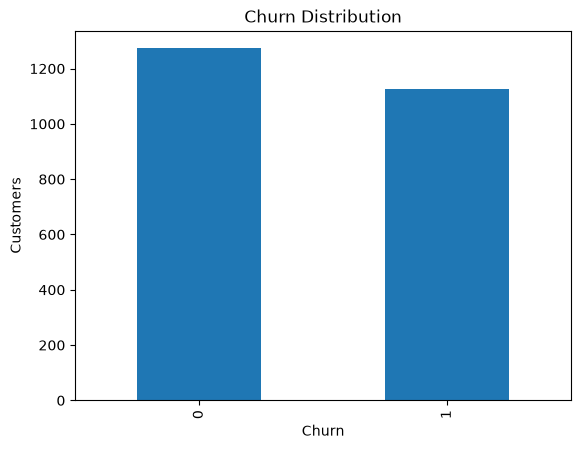

In [298]:
import matplotlib.pyplot as plt

master_df["churn_next_60d"].value_counts().plot(
    kind="bar"
)

plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Customers")

plt.show()

## Hypothesis 1: Churn Is a Significant Business Problem

### Finding

The churn analysis reveals that customer attrition is a major business concern.

Results:

- Total Customers: 2,400
- Retained Customers: 1,273 (53.04%)
- Churned Customers: 1,127 (46.96%)

### Business Insight

Nearly half of the customer base churned within the next 60 days, indicating a high customer attrition rate.

A churn rate of approximately 47% suggests that customer retention is a critical business challenge and requires immediate attention.

Even a small improvement in customer retention could significantly increase customer lifetime value, reduce acquisition costs, and improve overall profitability.

### Conclusion

The dataset confirms that churn is a substantial business problem affecting a large portion of customers.

### Status

✅ Hypothesis Confirmed

## Hypothesis 2: Younger Customers Churn More Frequently Than Older Customers

### Objective

To determine whether customer age group influences churn behavior.

Understanding age-based churn patterns can help the business design targeted retention campaigns for different customer segments.

### Analysis Approach

The churn rate will be compared across all age groups to identify whether younger customers exhibit higher churn tendencies than older customers.

### Expected Business Value

If younger customers are found to churn more frequently, the company can develop age-specific engagement, loyalty, and promotional strategies to improve retention.

In [299]:
age_churn = pd.crosstab(
    master_df["age_group"],
    master_df["churn_next_60d"],
    normalize="index"
) * 100

age_churn.round(2)

churn_next_60d,0,1
age_group,,
18-24,54.46,45.54
25-34,52.82,47.18
35-44,51.69,48.31
45+,53.64,46.36


### Finding

The analysis shows that churn rates are relatively similar across all age groups.

Observed Churn Rates:

- 18–24: 45.54%
- 25–34: 47.18%
- 35–44: 48.31%
- 45+: 46.36%

The highest churn rate is observed among customers aged 35–44 (48.31%), while the lowest churn rate is observed among customers aged 18–24 (45.54%).

The difference between age groups is relatively small (less than 3 percentage points), indicating that age alone is not a strong driver of customer churn.

### Business Insight

Customer attrition appears to be consistent across age segments.

This suggests that retention challenges are affecting customers broadly rather than being concentrated within a specific age group.

The company should focus on behavioral, engagement, purchase, and loyalty-related factors, which may have a stronger influence on churn than customer age.

### Conclusion

Age group does not appear to be a significant predictor of churn in this dataset.

### Status

❌ Hypothesis Rejected

## Hypothesis 3: Customer Loyalty Tier Influences Churn Behavior

### Objective

To determine whether customers with lower loyalty status are more likely to churn than customers with higher loyalty status.

### Expected Business Value

If lower-tier customers exhibit higher churn rates, the company can prioritize loyalty-building initiatives and targeted retention campaigns to improve customer lifetime value.

In [300]:
loyalty_churn = pd.crosstab(
    master_df["loyalty_tier"],
    master_df["churn_next_60d"],
    normalize="index"
) * 100

loyalty_churn.round(2)

churn_next_60d,0,1
loyalty_tier,,
Gold,59.25,40.75
Platinum,62.86,37.14
Silver,51.19,48.81


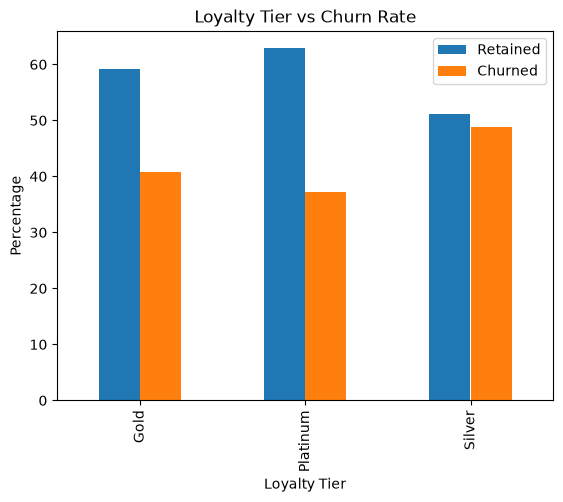

In [301]:
loyalty_churn.plot(kind="bar")

plt.title("Loyalty Tier vs Churn Rate")
plt.xlabel("Loyalty Tier")
plt.ylabel("Percentage")
plt.legend(["Retained", "Churned"])

plt.show()

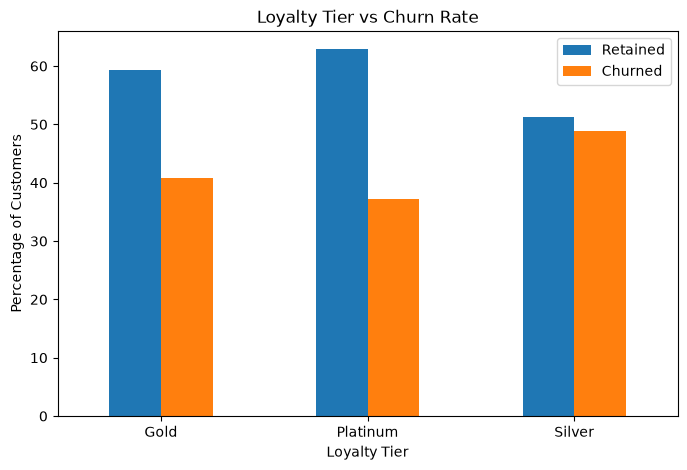

In [302]:
import matplotlib.pyplot as plt

loyalty_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Loyalty Tier vs Churn Rate")
plt.xlabel("Loyalty Tier")
plt.ylabel("Percentage of Customers")
plt.legend(["Retained", "Churned"])
plt.xticks(rotation=0)

plt.show()

### Finding

The analysis reveals a clear relationship between loyalty tier and customer churn.

- Platinum customers have the lowest churn rate at **37.14%**.
- Gold customers have a churn rate of **40.75%**.
- Silver customers have the highest churn rate at **48.81%**.

The results indicate that customers with stronger loyalty status are less likely to churn compared to lower-tier customers.

The difference between Platinum (37.14%) and Silver (48.81%) customers is approximately **11.67 percentage points**, suggesting that loyalty programs may play an important role in customer retention.

Therefore, the hypothesis is supported by the data.

### Business Insight

Customers in higher loyalty tiers demonstrate better retention behavior.

This suggests that loyalty programs provide meaningful business value by encouraging repeat engagement and reducing customer attrition.

The company should consider:

- Encouraging Silver customers to move into higher loyalty tiers.
- Offering tier-up rewards and exclusive benefits.
- Creating retention campaigns targeted at lower-tier customers.
- Increasing engagement incentives for customers who are close to reaching Gold or Platinum status.

Strengthening the loyalty program could help reduce future churn and improve customer lifetime value.

### Conclusion

✅ Hypothesis Confirmed

Customers with higher loyalty tiers churn less frequently than customers in lower loyalty tiers.

Platinum customers exhibit the strongest retention performance, while Silver customers show the highest churn risk.

## Hypothesis 4: Customers With Longer Inactivity Are More Likely To Churn

### Business Question

Do customers who have not visited the platform recently exhibit higher churn rates?

### Why This Matters

Customer inactivity is often an early warning sign of disengagement.

If customers who have not visited recently are more likely to churn, the business can proactively target inactive customers with re-engagement campaigns before they are lost.

### Expected Business Value

Identifying inactivity-based churn risk can help the company prioritize retention efforts and improve customer lifetime value.

In [303]:
inactive_churn = pd.crosstab(
    pd.cut(
        master_df["last_visit_days_ago"],
        bins=[0, 7, 15, 30, 60],
        labels=["0-7 Days", "8-15 Days", "16-30 Days", "31-60 Days"]
    ),
    master_df["churn_next_60d"],
    normalize="index"
) * 100

inactive_churn.round(2)

churn_next_60d,0,1
last_visit_days_ago,,
0-7 Days,77.80,22.20
8-15 Days,65.43,34.57
16-30 Days,38.97,61.03
31-60 Days,11.64,88.36


### Finding

The analysis shows a strong relationship between customer inactivity and churn.

| Last Visit Period | Churn Rate |
|------------------|------------|
| 0–7 Days | 22.20% |
| 8–15 Days | 34.57% |
| 16–30 Days | 61.03% |
| 31–60 Days | 88.36% |

Customers who visited within the last 7 days have a churn rate of only **22.20%**.

However, churn increases steadily as inactivity grows:

- 8–15 days inactive → 34.57% churn
- 16–30 days inactive → 61.03% churn
- 31–60 days inactive → 88.36% churn

Customers inactive for more than 30 days are nearly four times more likely to churn than recently active customers.

The results strongly support the hypothesis that customer inactivity is a major predictor of churn.

### Business Insight

Customer inactivity appears to be one of the strongest indicators of future churn.

As the number of days since the last visit increases, customer engagement drops significantly and churn risk rises sharply.

The company should:

- Monitor customers who have not visited for more than 15 days.
- Trigger automated re-engagement campaigns for inactive users.
- Send personalized offers and reminders before customers reach 30 days of inactivity.
- Prioritize highly inactive customers for retention interventions.

Reducing customer inactivity could significantly improve retention rates and customer lifetime value.

### Conclusion

✅ Hypothesis Confirmed

Customers with longer inactivity periods are substantially more likely to churn.

The highest-risk segment consists of customers who have not visited the platform for 31–60 days, with an extremely high churn rate of 88.36%.

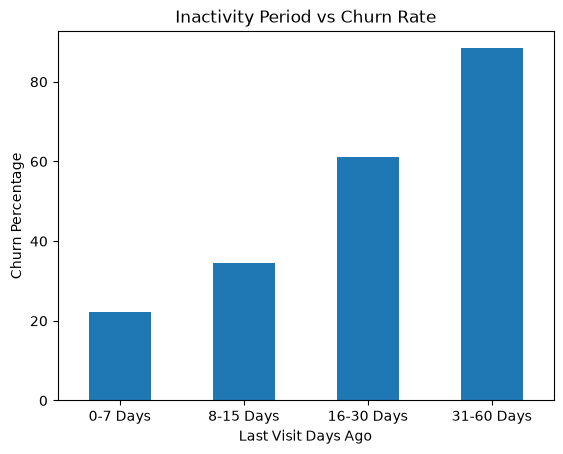

In [304]:
inactive_churn[1].plot(kind="bar")

plt.title("Inactivity Period vs Churn Rate")
plt.xlabel("Last Visit Days Ago")
plt.ylabel("Churn Percentage")
plt.xticks(rotation=0)

plt.show()

### Finding

- Churn rate increases from 22.20% (0-7 days inactive) to 88.36% (31-60 days inactive).
- Customers inactive for 30+ days show extremely high churn risk.
- Inactivity is strongly associated with customer churn.

### Business Insight

The business should target customers who have not visited for more than 15 days using re-engagement campaigns and personalized offers.

### Conclusion

✅ Hypothesis Supported

## Hypothesis 5: Customers With Lower Website Engagement Are More Likely To Churn

### Business Question

Do customers with fewer website sessions exhibit higher churn rates?

### Why This Matters

Website engagement reflects customer interest and activity. Customers who rarely visit the platform may be at higher risk of disengagement and eventual churn.

### Expected Business Value

If low engagement is associated with higher churn, the company can identify at-risk customers early and increase engagement through targeted campaigns and personalized recommendations.

In [305]:
engagement_churn = pd.crosstab(
    pd.cut(
        master_df["sessions_30d"],
        bins=[0, 3, 7, 12, 25],
        labels=["Low", "Medium", "High", "Very High"]
    ),
    master_df["churn_next_60d"],
    normalize="index"
) * 100

engagement_churn.round(2)

churn_next_60d,0,1
sessions_30d,,
Low,38.71,61.29
Medium,55.26,44.74
High,69.23,30.77
Very High,81.35,18.65


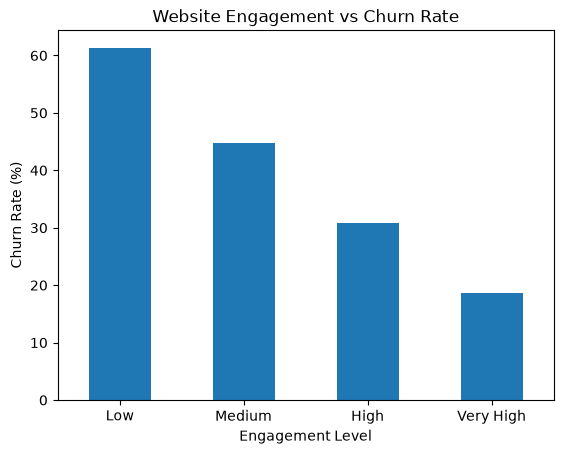

In [306]:
engagement_churn[1].plot(kind="bar")

plt.title("Website Engagement vs Churn Rate")
plt.xlabel("Engagement Level")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Finding

- Customers with Low engagement have the highest churn rate at 61.29%.
- Churn decreases consistently as website engagement increases.
- Very High engagement customers have the lowest churn rate at 18.65%.
- Customer engagement is strongly associated with retention.

### Business Insight

Increasing customer engagement through personalized recommendations, marketing campaigns, and improved user experience may significantly reduce churn.

### Conclusion

✅ Hypothesis Supported

## Hypothesis 6: Customers With More Abandoned Carts Are More Likely To Churn

### Business Question

Do customers with more abandoned carts exhibit higher churn rates?

### Why This Matters

Abandoned carts indicate purchase intent that was not completed. Customers who frequently abandon carts may be dissatisfied, price-sensitive, or losing interest in the platform.

### Expected Business Value

Understanding the relationship between abandoned carts and churn can help the business recover potential customers through cart reminders, discounts, and targeted retention campaigns.

In [307]:
cart_churn = pd.crosstab(
    pd.cut(
        master_df["abandoned_carts_30d"],
        bins=[-1, 0, 1, 3, 7],
        labels=["None", "Low", "Medium", "High"]
    ),
    master_df["churn_next_60d"],
    normalize="index"
) * 100

cart_churn.round(2)

churn_next_60d,0,1
abandoned_carts_30d,,
None,43.93,56.07
Low,58.15,41.85
Medium,73.78,26.22
High,93.10,6.90


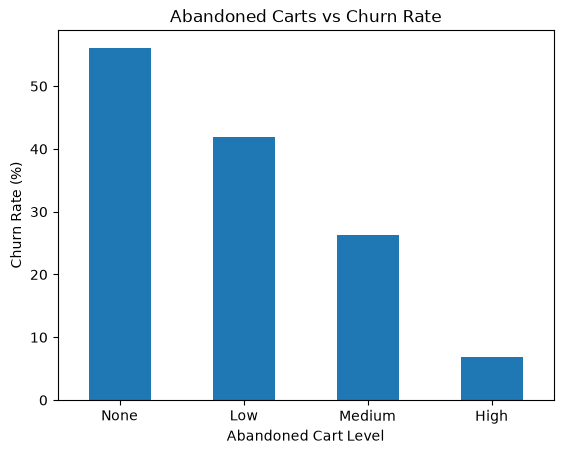

In [308]:
cart_churn[1].plot(kind="bar")

plt.title("Abandoned Carts vs Churn Rate")
plt.xlabel("Abandoned Cart Level")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Finding

- Customers with no abandoned carts have the highest churn rate at 56.07%.
- Churn decreases as abandoned cart activity increases.
- Customers with high abandoned cart activity show the lowest churn rate at 6.90%.
- The results do not support the expected relationship between abandoned carts and churn.

### Business Insight

Abandoned cart activity may indicate ongoing customer interest rather than disengagement. Customers who continue browsing and adding products to their carts appear more likely to remain active.

### Conclusion

❌ Hypothesis Not Supported

## Hypothesis 7: Customer Acquisition Channel Influences Churn

### Business Question

Do customers acquired through different acquisition channels exhibit different churn behavior?

### Why This Matters

Marketing teams invest heavily across acquisition channels. If certain channels attract customers who churn more frequently, marketing budgets can be optimized toward higher-quality acquisition sources.

### Expected Business Value

Identifying high-churn acquisition channels can help improve marketing ROI and customer retention.

In [309]:
channel_churn = pd.crosstab(
    master_df["acquisition_channel"],
    master_df["churn_next_60d"],
    normalize="index"
) * 100

channel_churn.round(2)

churn_next_60d,0,1
acquisition_channel,,
Google Search,49.57,50.43
Influencer,52.38,47.62
Instagram,50.10,49.90
Marketplace,50.88,49.12
Organic,60.18,39.82
Referral,57.83,42.17


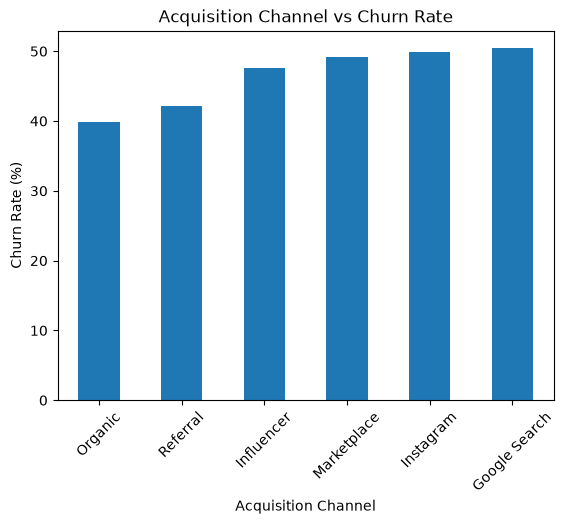

In [310]:
channel_churn[1].sort_values().plot(kind="bar")

plt.title("Acquisition Channel vs Churn Rate")
plt.xlabel("Acquisition Channel")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=45)

plt.show()

### Finding

- Google Search customers show the highest churn rate at 50.43%.
- Instagram (49.90%) and Marketplace (49.12%) customers also exhibit high churn rates.
- Organic customers have the lowest churn rate at 39.82%.
- Referral customers churn at 42.17%, lower than most paid acquisition channels.
- Differences exist across channels, although the gap is moderate.

### Business Insight

Organic and referral channels appear to acquire higher-quality customers with better retention. Marketing investments should prioritize channels that attract long-term customers rather than only maximizing acquisition volume.

### Conclusion

✅ Hypothesis Supported

## Hypothesis 8: Marketing Consent Reduces Churn

### Business Question

Do customers who provide marketing consent churn less frequently than customers who opt out?

### Why This Matters

Customers who allow marketing communication can be reached through promotional campaigns, product recommendations, and retention offers.

### Expected Business Value

If marketing consent is associated with lower churn, the business can encourage more customers to opt into marketing communications.

In [311]:
consent_churn = pd.crosstab(
    master_df["marketing_consent"],
    master_df["churn_next_60d"],
    normalize="index"
) * 100

consent_churn.round(2)

churn_next_60d,0,1
marketing_consent,,
No,52.03,47.97
Yes,53.41,46.59


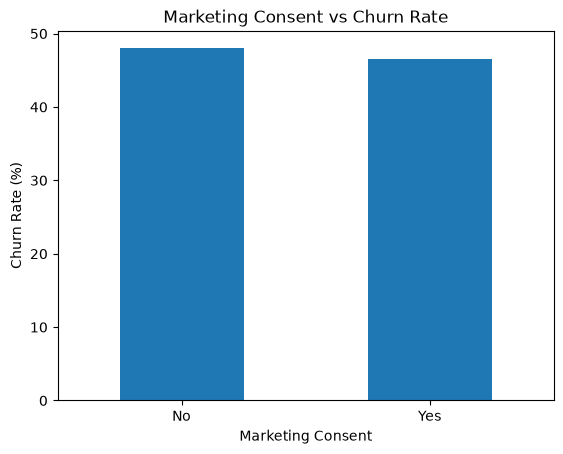

In [312]:
consent_churn[1].plot(kind="bar")

plt.title("Marketing Consent vs Churn Rate")
plt.xlabel("Marketing Consent")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Finding

- Customers with marketing consent have a churn rate of 46.59%.
- Customers without marketing consent have a churn rate of 47.97%.
- The difference between the two groups is only 1.38%.
- Marketing consent alone does not appear to be a strong predictor of churn.

### Business Insight

While marketing consent may improve communication opportunities, it does not significantly impact customer retention on its own.

### Conclusion

❌ Hypothesis Not Supported

## Hypothesis 9: Customers With Returned Orders Churn More Frequently

### Why This Matters

Product returns may indicate dissatisfaction with product quality, expectations, or delivery experience. Customers who frequently return products may be at higher risk of churn.

### Expected Business Value

If returned orders are associated with higher churn, the company can identify dissatisfied customers early and launch targeted retention programs.

In [313]:
return_churn = pd.crosstab(
    orders["returned"],
    churn["churn_next_60d"],
    normalize="index"
) * 100

return_churn.round(2)

churn_next_60d,0,1
returned,,
0,53.13,46.87
1,51.85,48.15


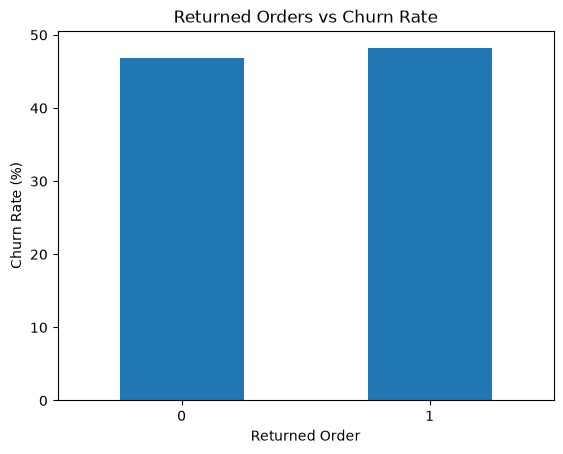

In [314]:
return_churn[1].plot(kind="bar")

plt.title("Returned Orders vs Churn Rate")
plt.xlabel("Returned Order")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Finding

- Customers without returned orders have a churn rate of 46.87%.
- Customers with returned orders have a churn rate of 48.15%.
- The difference in churn rate is very small (1.28%).

### Business Insight

Order returns alone do not appear to be a strong predictor of churn in this dataset. Other behavioral factors such as engagement, inactivity, and loyalty tier have a much stronger relationship with customer churn.

### Conclusion

❌ Hypothesis Not Supported

## Hypothesis 10: Customers With Reopened Support Tickets Churn More Frequently

### Why This Matters

Reopened support tickets often indicate unresolved customer issues and dissatisfaction with the support experience. Customers whose issues require repeated follow-ups may be more likely to leave the platform.

### Expected Business Value

If reopened tickets are associated with higher churn, the business can prioritize unresolved cases and improve support quality to reduce customer attrition.

In [315]:
support_customer = support.groupby("customer_id")["reopened"].max().reset_index()

support_churn_df = support_customer.merge(
    churn[["customer_id", "churn_next_60d"]],
    on="customer_id",
    how="left"
)

support_churn = pd.crosstab(
    support_churn_df["reopened"],
    support_churn_df["churn_next_60d"],
    normalize="index"
) * 100

support_churn.round(2)

churn_next_60d,0,1
reopened,,
0,51.93,48.07
1,57.19,42.81


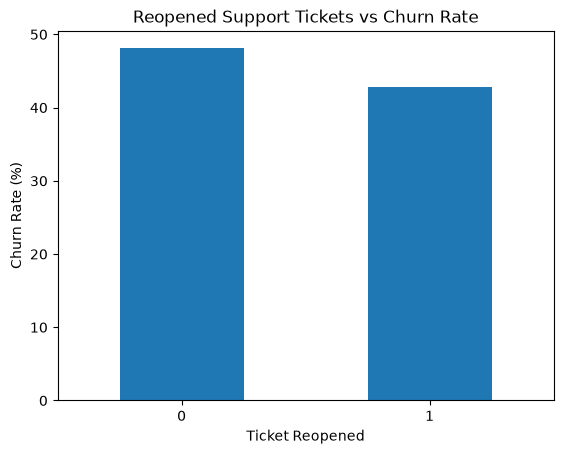

In [316]:
support_churn[1].plot(kind="bar")

plt.title("Reopened Support Tickets vs Churn Rate")
plt.xlabel("Ticket Reopened")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Finding

- Customers without reopened support tickets have a churn rate of 48.07%.
- Customers with reopened support tickets have a churn rate of 42.81%.
- Customers who reopened tickets actually show slightly lower churn rates.

### Business Insight

The results suggest that customers who engage with support and continue following up on their issues may remain more connected to the business. Active support engagement may help prevent churn by resolving customer concerns.

### Conclusion

❌ Hypothesis Not Supported

## Hypothesis 11: High Spending Customers Churn Less Frequently

### Why This Matters

Customers who spend more money typically demonstrate stronger engagement and a higher commitment to the brand. These customers are expected to have a lower likelihood of churn compared to low-spending customers.

### Expected Business Value

If high-value customers are found to churn less frequently, the business can focus retention efforts on low-spending segments while protecting high-value customers through loyalty programs and personalized experiences.

In [317]:
customer_spend = orders.groupby("customer_id")["gross_amount"].sum().reset_index()

customer_spend.columns = ["customer_id", "total_spend"]

customer_spend["spend_segment"] = pd.qcut(
    customer_spend["total_spend"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

spend_churn_df = customer_spend.merge(
    churn[["customer_id", "churn_next_60d"]],
    on="customer_id",
    how="left"
)

spend_churn = pd.crosstab(
    spend_churn_df["spend_segment"],
    spend_churn_df["churn_next_60d"],
    normalize="index"
) * 100

spend_churn.round(2)

churn_next_60d,0,1
spend_segment,,
Low,22.67,77.33
Medium,51.33,48.67
High,62.17,37.83
Very High,76.00,24.00


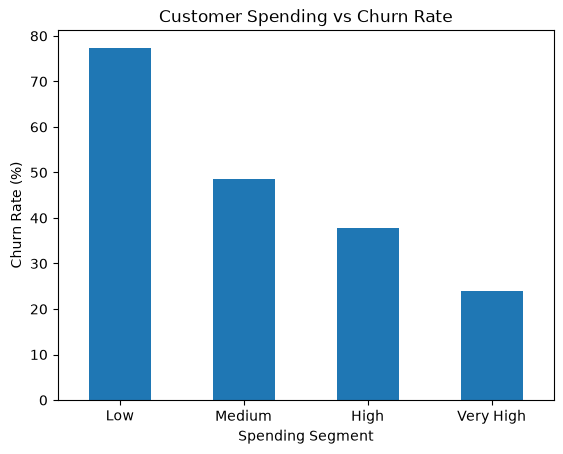

In [318]:
spend_churn[1].plot(kind="bar")

plt.title("Customer Spending vs Churn Rate")
plt.xlabel("Spending Segment")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Finding

- Customers in the Low Spending segment have the highest churn rate at 77.33%.
- Churn decreases consistently as customer spending increases.
- Customers in the Very High Spending segment have the lowest churn rate at 24.00%.
- A clear inverse relationship exists between customer spending and churn.

### Business Insight

Low-spending customers appear to be less engaged and more likely to leave the platform. Increasing purchase frequency and basket size through targeted promotions, loyalty rewards, and personalized recommendations may help improve retention.

### Conclusion

✅ Hypothesis Supported

Customers with higher total spending are significantly less likely to churn. Customer monetary value is a strong indicator of retention and should be considered in future churn prediction models.

# Hypothesis 12: Customers With More Orders Churn Less Frequently

### Why This Matters

Purchase frequency is a strong indicator of customer engagement and satisfaction. Customers who place orders regularly are more likely to remain active and loyal to the platform.

### Expected Business Value

If customers with fewer orders show higher churn, the business can target low-frequency buyers with retention campaigns, loyalty rewards, and personalized offers.

In [319]:
order_count = orders.groupby("customer_id")["order_id"].count().reset_index()

order_count.columns = ["customer_id", "total_orders"]

order_churn_df = order_count.merge(
    churn[["customer_id", "churn_next_60d"]],
    on="customer_id",
    how="left"
)

order_churn = pd.crosstab(
    pd.cut(
        order_churn_df["total_orders"],
        bins=[0, 2, 4, 7, 20],
        labels=["Low", "Medium", "High", "Very High"]
    ),
    order_churn_df["churn_next_60d"],
    normalize="index"
) * 100

order_churn.round(2)

churn_next_60d,0,1
total_orders,,
Low,27.19,72.81
Medium,55.39,44.61
High,68.31,31.69
Very High,84.19,15.81


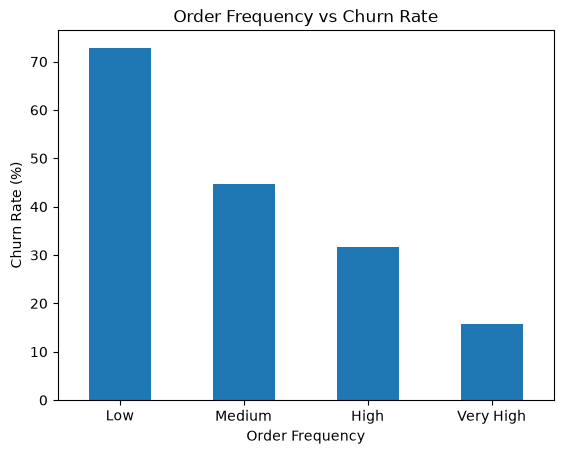

In [320]:
order_churn[1].plot(kind="bar")

plt.title("Order Frequency vs Churn Rate")
plt.xlabel("Order Frequency")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Finding

- Customers with low order frequency have the highest churn rate at 72.81%.
- Churn decreases consistently as order frequency increases.
- Customers with very high order frequency show the lowest churn rate at 15.81%.
- Frequent purchasing behavior is strongly associated with customer retention.

### Business Insight

Customers with low purchase frequency exhibit substantially higher churn rates.
Retention campaigns should prioritize customers with declining order activity before they become inactive.

### Conclusion

✅ Hypothesis Supported